In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [9]:
db= mysql.connector.connect(
    host="localhost",
    user="root",
    password="@m1nu",
    database="bank"
)

In [10]:
query=" select * from banking"

In [11]:
df= pd.read_sql(query, db)

C:\Users\vs339\AppData\Local\Temp\ipykernel_15696\3387444155.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df= pd.read_sql(query, db)


In [12]:
db.close()

In [13]:
df.head

<bound method NDFrame.head of      ï»¿Client ID              Name  Age  Location ID Joined Bank  \
0        IND81288     Raymond Mills   24        34324  06-05-2019   
1        IND65833     Julia Spencer   23        42205  10-12-2001   
2        IND47499    Stephen Murray   27         7314  25-01-2010   
3        IND72498    Virginia Garza   40        34594  28-03-2019   
4        IND60181   Melissa Sanders   46        41269  20-07-2012   
...           ...               ...  ...          ...         ...   
2995     IND66827         Earl Hall   82         8760  09-10-2014   
2996     IND40556  Billy Williamson   44        32837  05-02-2009   
2997     IND72414      Victor Black   70        36088  29-12-2009   
2998     IND46652       Andrew Ford   56        24871  13-02-2006   
2999     IND40216        Amy Nguyen   79        38518  08-12-2005   

          Banking Contact Nationality                     Occupation  \
0          Anthony Torres    American           Safety Technician IV 

In [14]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [15]:
bins=[0, 100000, 300000, float("inf")]
labels=["Low", "Mediumh", "High"]

df["income band"]= pd.cut(df["Estimated Income"], bins=bins, labels=labels, right=False)

<Axes: xlabel='income band'>

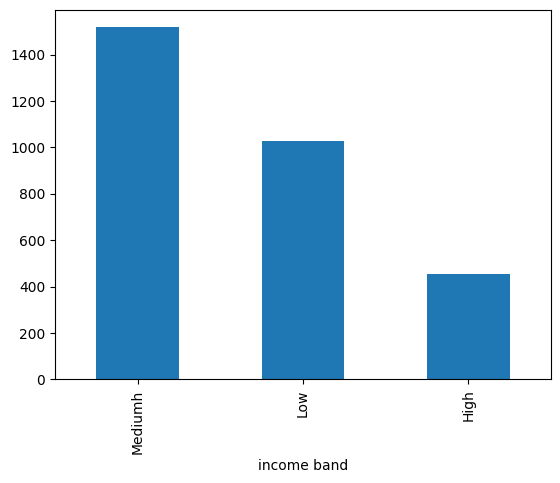

In [16]:
df["income band"].value_counts().plot(kind="bar")

In [17]:
df.columns

Index(['ï»¿Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'income band'],
      dtype='object')

In [18]:
# examine the distribution of unique categories incategorical columns
categorical_cols=df[["BRId", "GenderId",'Amount of Credit Cards','Fee Structure','Nationality', 'Occupation',  'Loyalty Classification', 'IAId', 'Properties Owned',
       'Risk Weighting','income band']].columns

for col in categorical_cols:
       print("value counts for {'col'}")
       display(df[col].value_counts())
       

value counts for {'col'}


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

value counts for {'col'}


GenderId
2    1512
1    1488
Name: count, dtype: int64

value counts for {'col'}


...

Properties Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64

value counts for {'col'}


Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

value counts for {'col'}


income band
Mediumh    1517
Low        1027
High        456
Name: count, dtype: int64

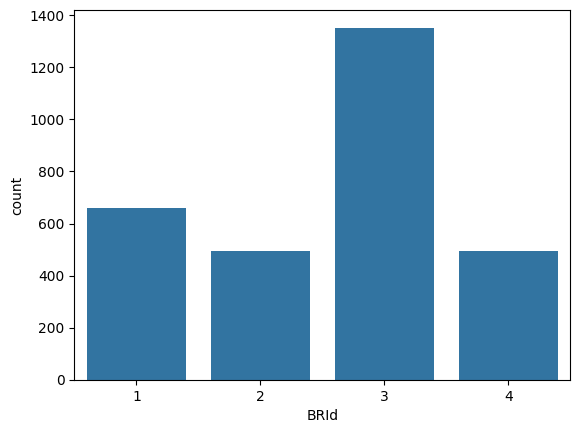

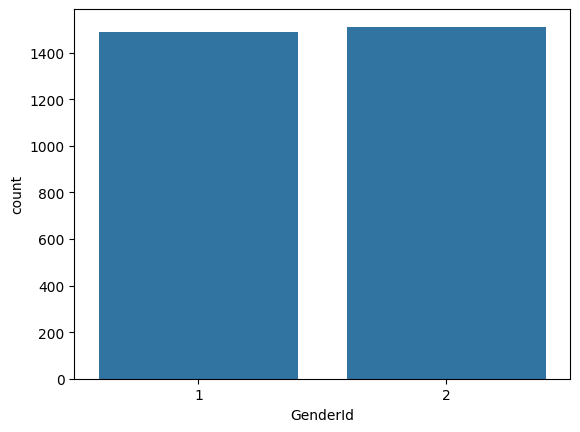

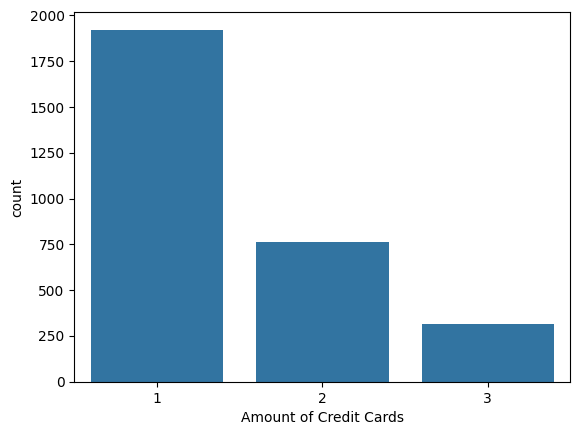

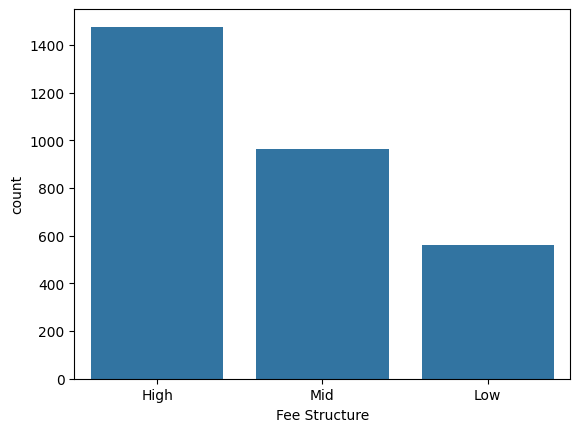

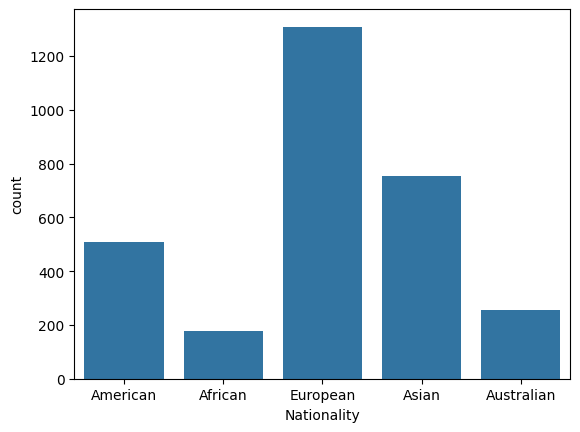

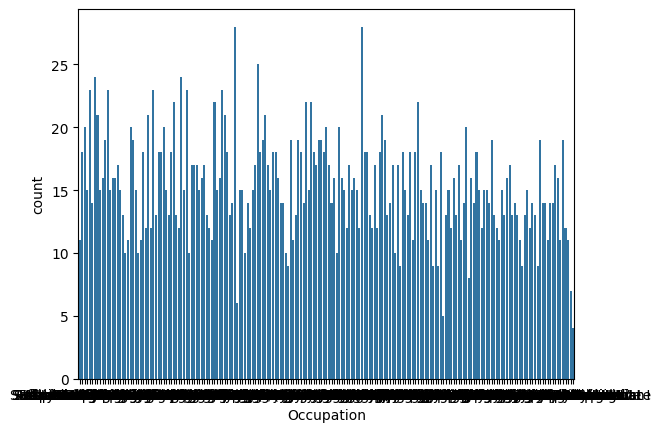

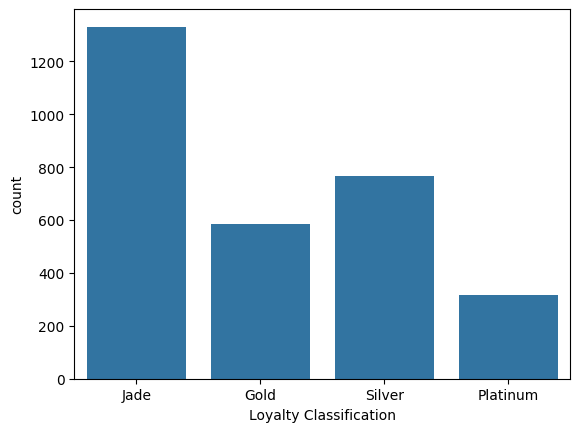

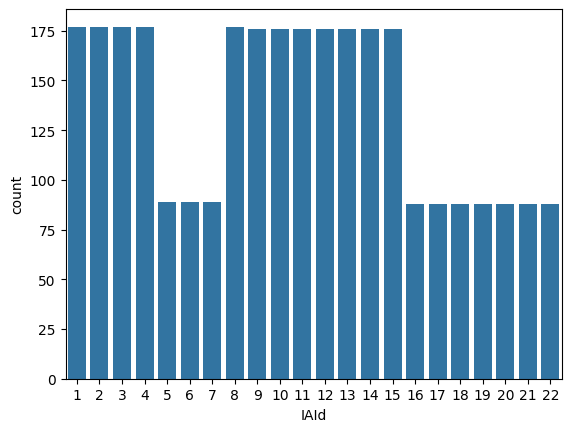

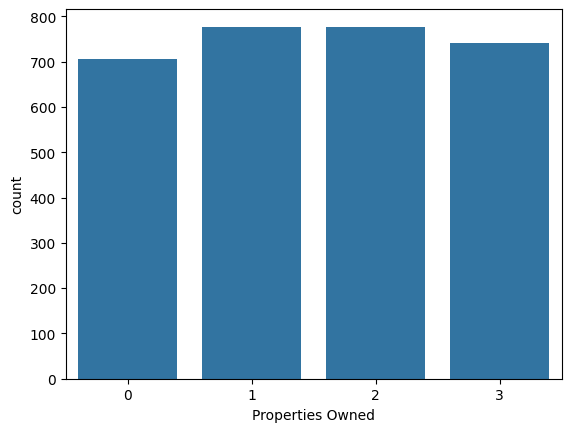

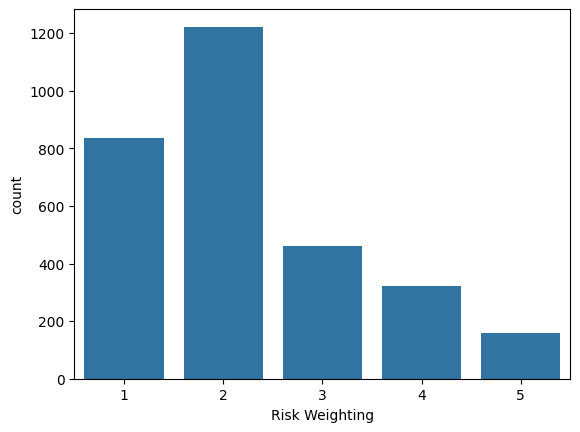

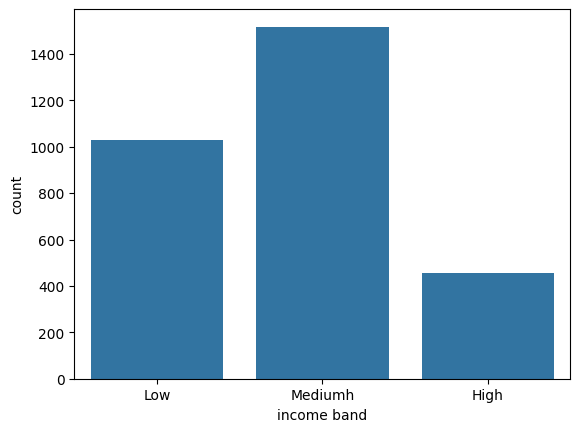

In [19]:
#univariate Analysis
for i, predictor in enumerate(df[["BRId", "GenderId",'Amount of Credit Cards','Fee Structure','Nationality', 'Occupation',  'Loyalty Classification', 'IAId', 'Properties Owned',
       'Risk Weighting','income band']].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

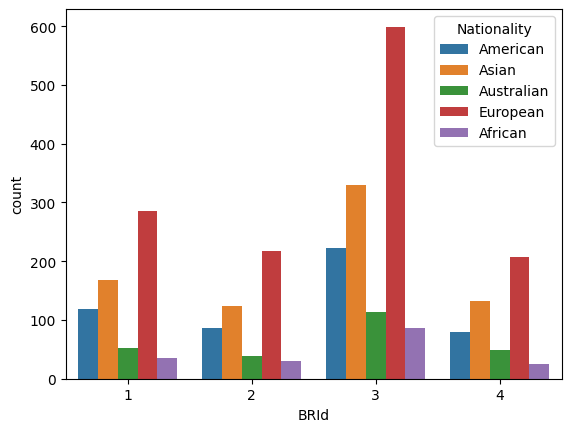

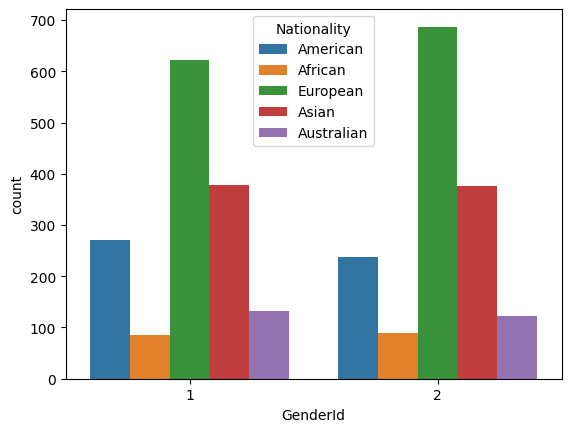

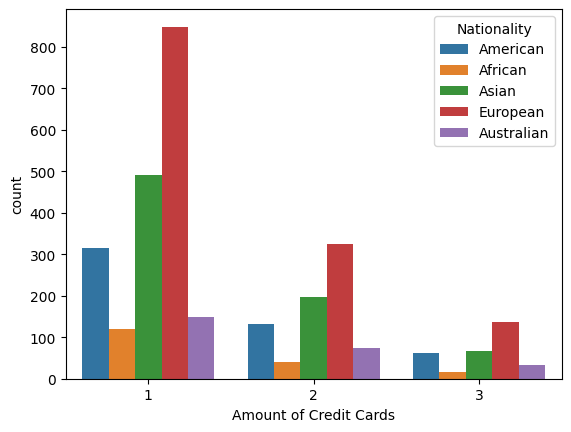

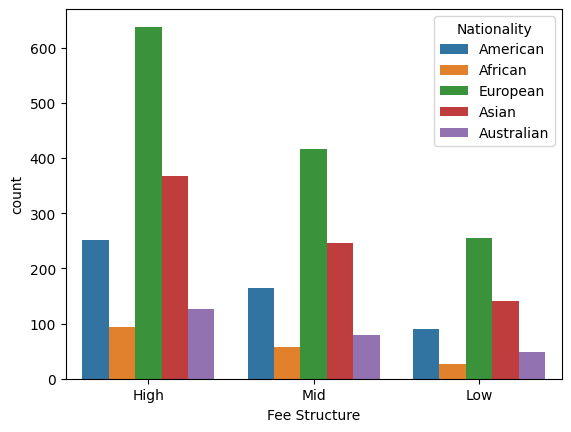

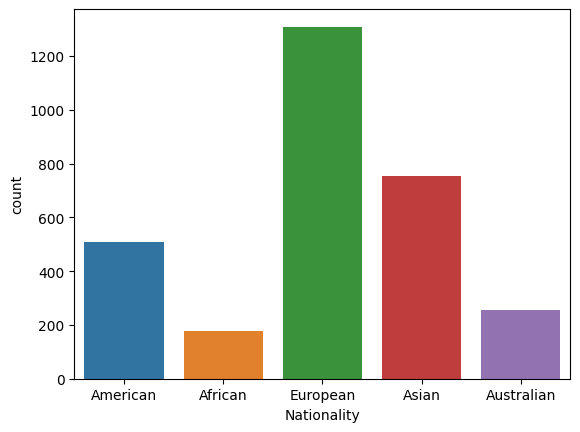

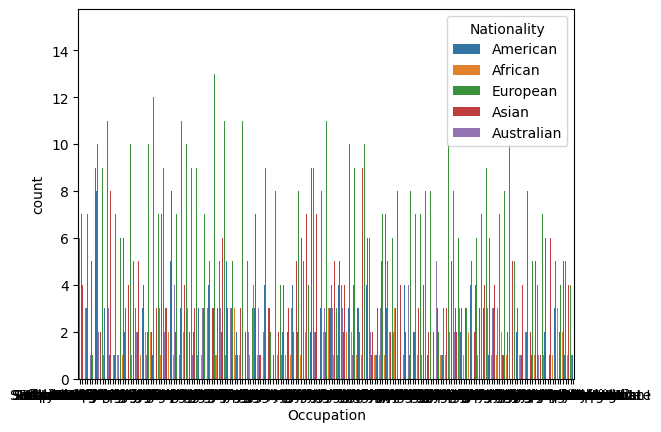

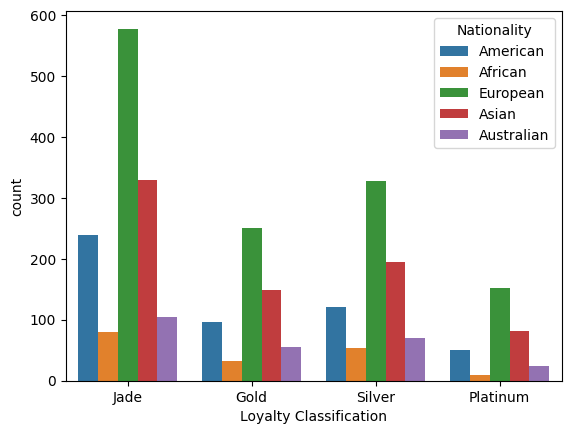

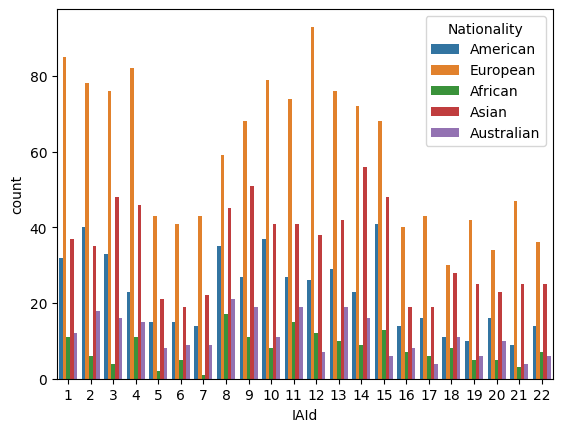

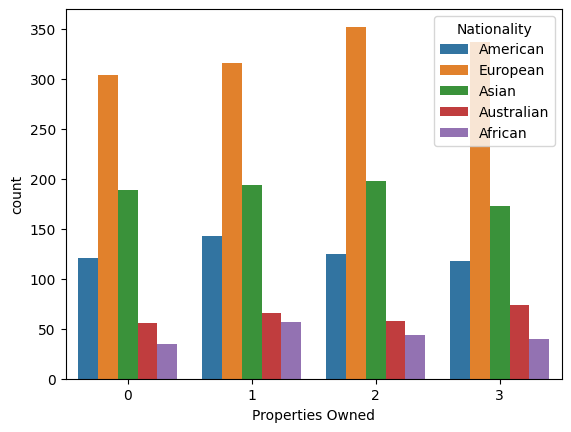

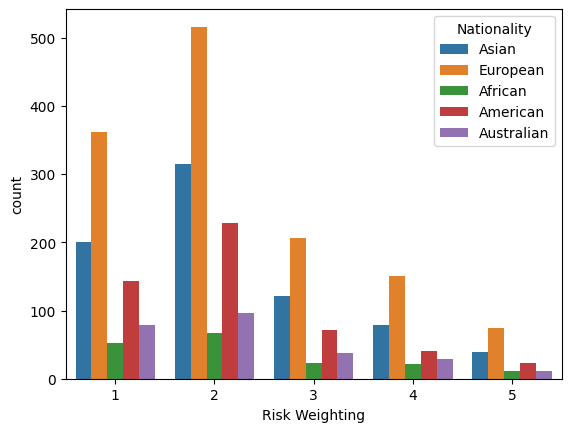

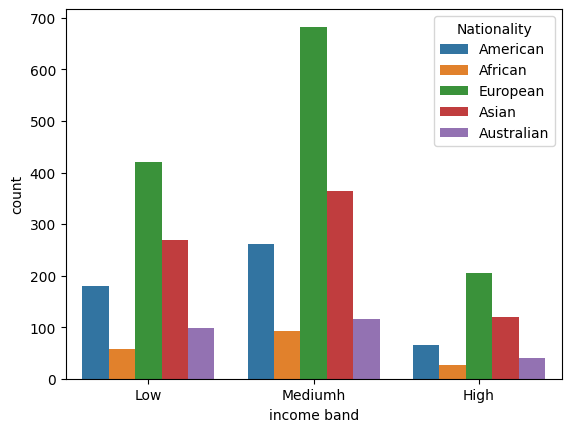

In [20]:
## Bivariate Analysis
for i, predictor in enumerate(df[["BRId", "GenderId",'Amount of Credit Cards','Fee Structure','Nationality', 'Occupation',  'Loyalty Classification', 'IAId', 'Properties Owned',
       'Risk Weighting','income band']].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Nationality')

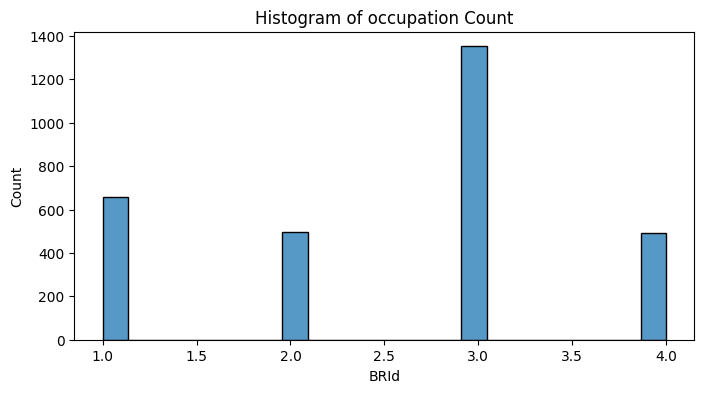

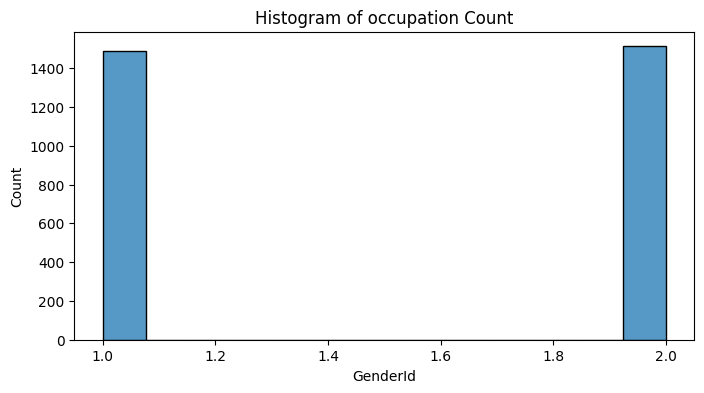

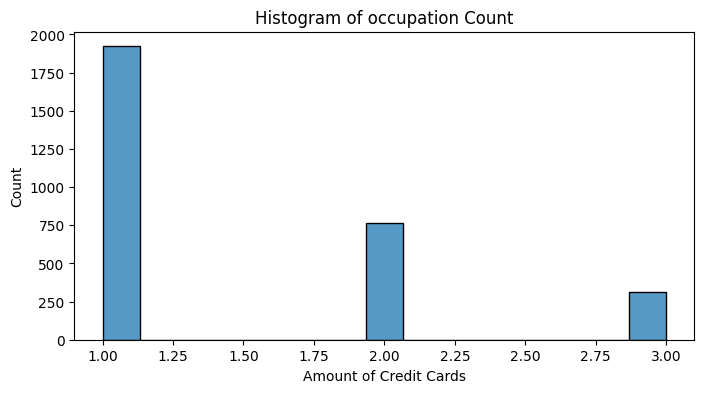

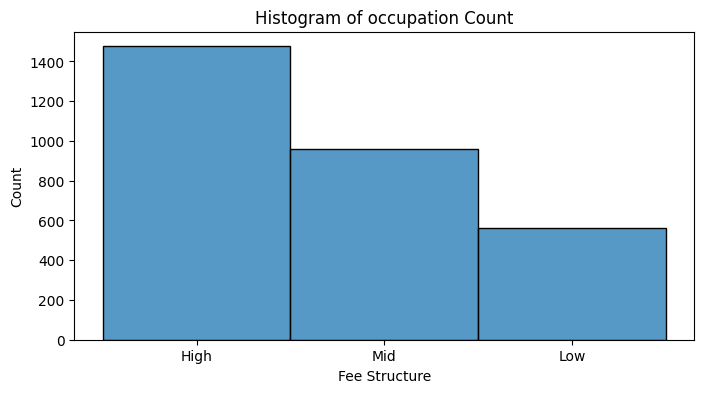

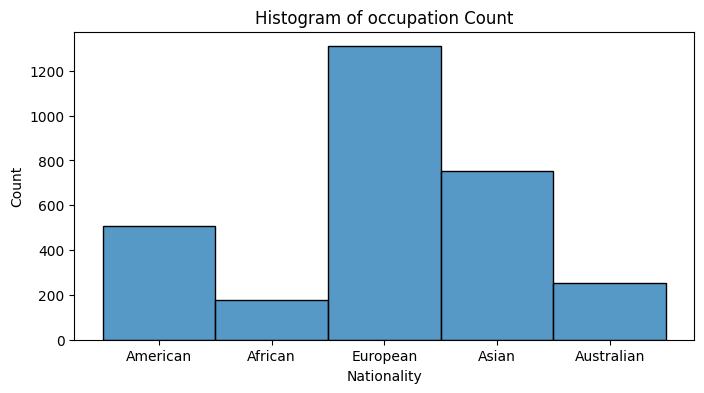

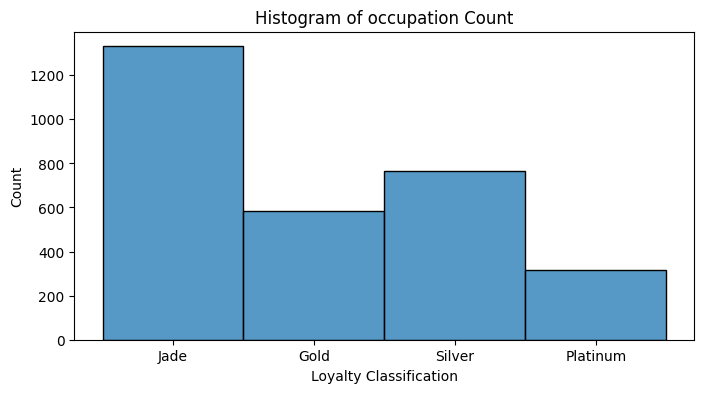

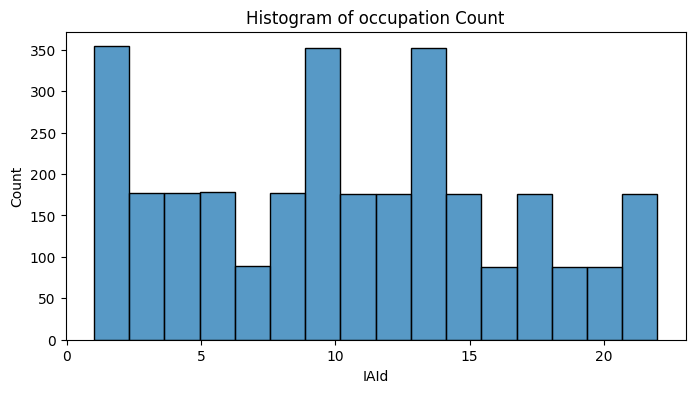

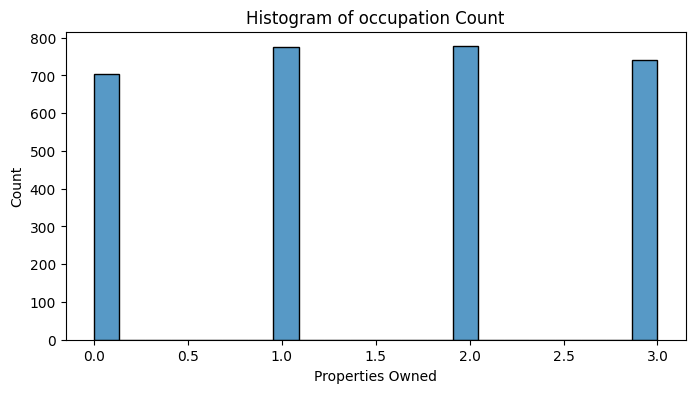

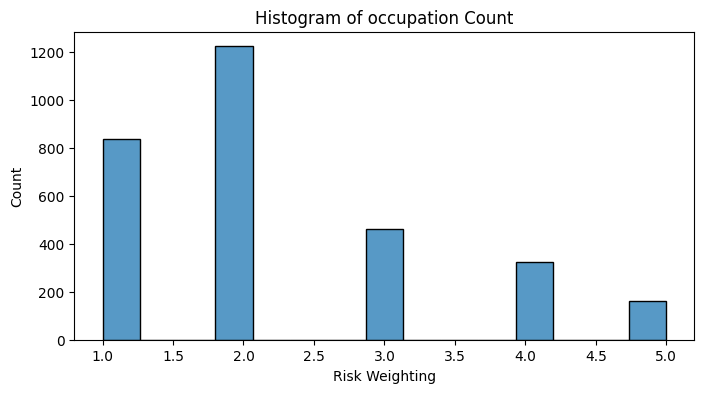

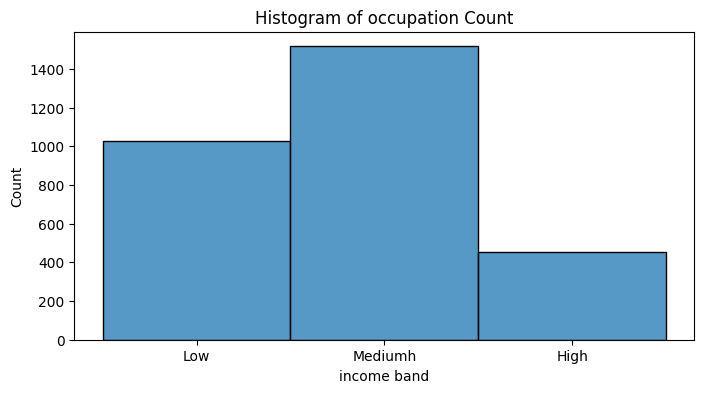

In [21]:
# Histplot of value count  for different occupation 

for col in categorical_cols:
    if col=="Occupation":
        continue
    plt.figure(figsize=(8,4))
    sns.histplot(df[col])
    plt.title('Histogram of occupation Count')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [22]:
df.columns

Index(['ï»¿Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'income band'],
      dtype='object')

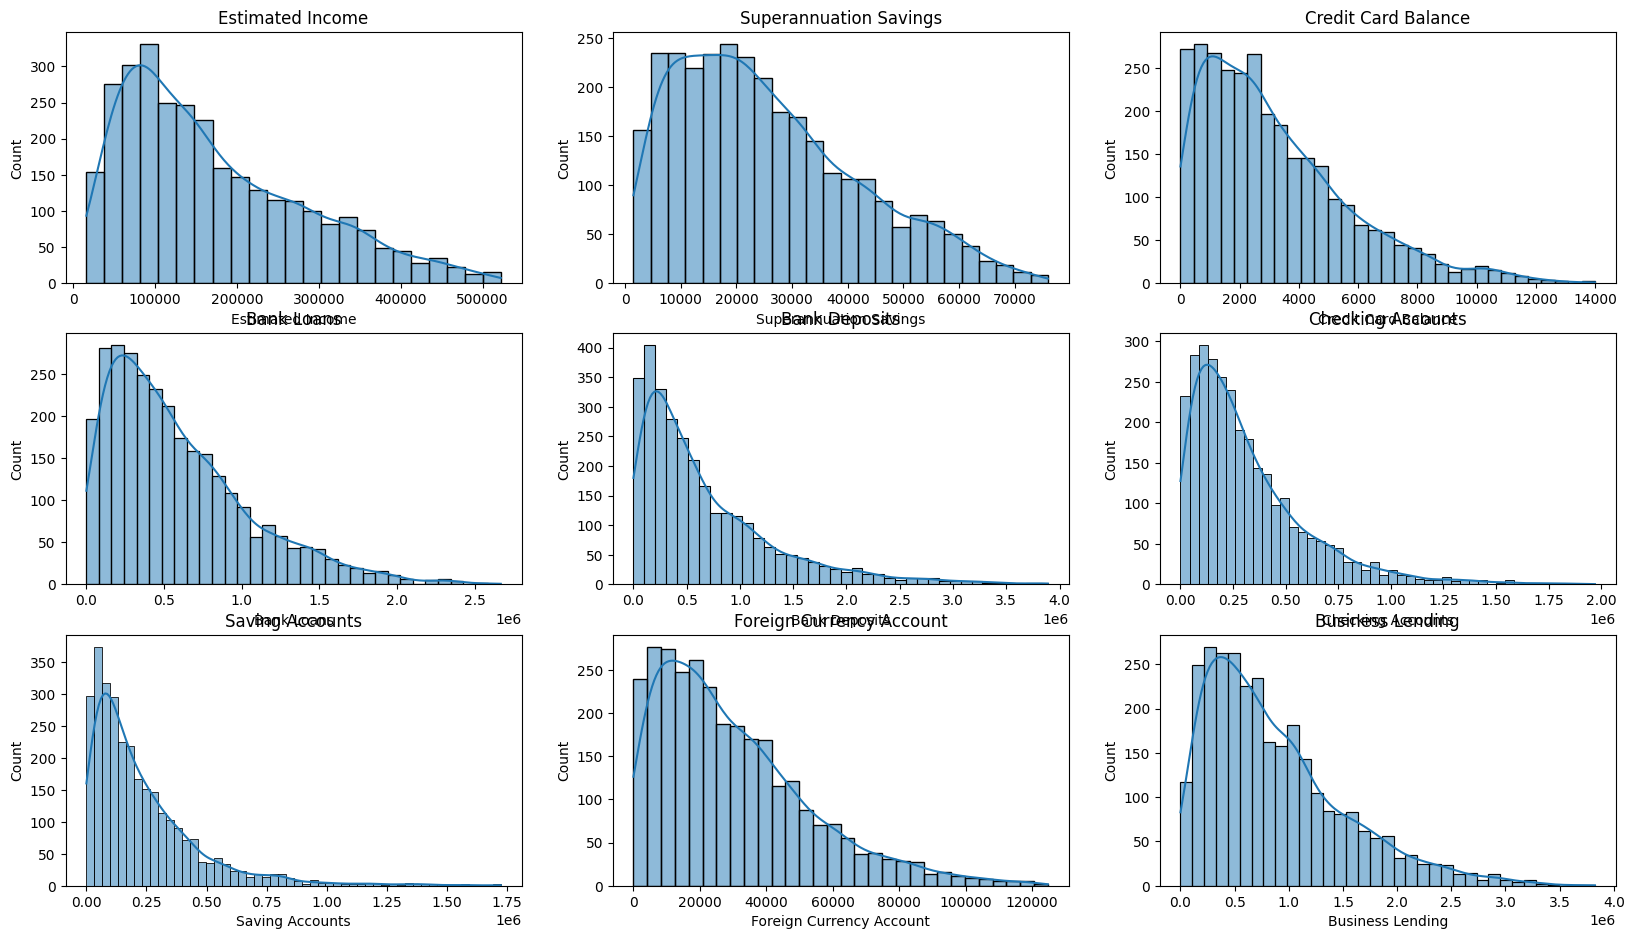

In [23]:
# Numerical Analysis
numerical_cols=df[['Estimated Income','Superannuation Savings','Credit Card Balance','Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending']].columns

#univariate anlysis and visualization
plt.figure(figsize=(20,15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.show()
    




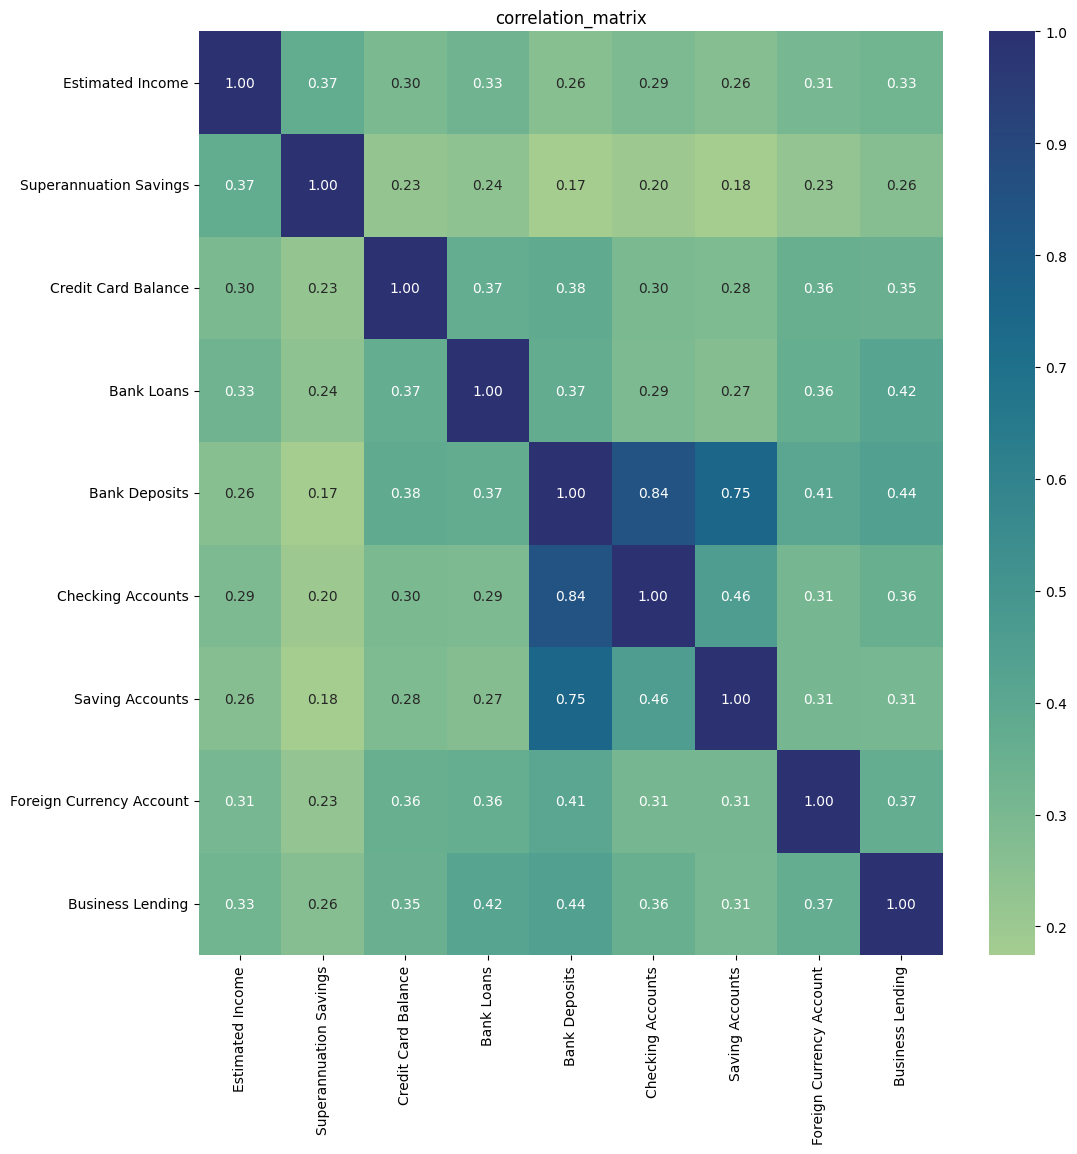

In [24]:
#Heatmaps
numerical_cols=df[['Estimated Income','Superannuation Savings','Credit Card Balance','Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending']].columns
correlation_matrix=df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt='.2f')
plt.title("correlation_matrix")
plt.show()

In [25]:
#Insights from Correlation Analysis
'''
1. Relationship Between Account Types :
Bank Deposits, Checking Accounts, and Saving Accounts show strong positive relationships. 
This indicates that customers with higher balances tend to maintain multiple types of accounts. These customers are generally 
financially stable and well-organized.

2. Credit Usage Behavior :
Credit Card Balance, Bank Loans, and Business Lending are moderately correlated. This suggests that 
customers who use one form of credit are likely to use others as well. Such customers may rely more on borrowed funds and can 
be considered relatively higher risk.

3. Role of Income :
Estimated Income shows only moderate correlation with other variables. This means income alone does not 
strongly determine financial behavior. Some customers with high income may not save much, while others with lower income may 
manage their finances more efficiently.

4. Foreign Currency Account Segment :
Foreign Currency Account has moderate correlation with multiple variables but does not 
strongly align with any specific group. This indicates a distinct customer segment, possibly consisting of international 
users or high-value clients.

5. Diversity in Customer Behavior :
Most variables have low to moderate correlations, indicating that customer behaviors are 
diverse. Each feature contributes unique information, which is beneficial for analysis and modeling.

6. Customer Segmentation Insight :
Two broad customer groups can be identified:
Stable Customers: Associated with deposits and savings accounts; financially secure and low risk.
Credit-Dependent Customers: Associated with credit cards and loans; higher usage of credit and potentially higher risk.

7. Risk Indicator :
Customers with high credit card balances along with active loans and business lending may be over-leveraged. 
This can serve as a potential risk indicator in financial analysis and modeling.

Conclusion :
The dataset highlights distinct financial behavior patterns. Account-related features indicate stability, while credit-related 
features highlight potential risk. Income alone is not a strong predictor, and customer segmentation should be based on multiple variables.'''


'\n1. Relationship Between Account Types :\nBank Deposits, Checking Accounts, and Saving Accounts show strong positive relationships. \nThis indicates that customers with higher balances tend to maintain multiple types of accounts. These customers are generally \nfinancially stable and well-organized.\n\n2. Credit Usage Behavior :\nCredit Card Balance, Bank Loans, and Business Lending are moderately correlated. This suggests that \ncustomers who use one form of credit are likely to use others as well. Such customers may rely more on borrowed funds and can \nbe considered relatively higher risk.\n\n3. Role of Income :\nEstimated Income shows only moderate correlation with other variables. This means income alone does not \nstrongly determine financial behavior. Some customers with high income may not save much, while others with lower income may \nmanage their finances more efficiently.\n\n4. Foreign Currency Account Segment :\nForeign Currency Account has moderate correlation with mult